In [1]:
import pandas as pd


In [2]:
#data = pd.read_csv("../data_collection/planet_history (2).csv")
data = pd.read_csv("../data_collection/planet_history.csv")
data.head()

,timestamp,planet_index,name,sector,biome,planet_environ_hazards,player_on_planet,isAvailableToPlay,in_major_order,missions_won,...,major_order_completed,planet_health,max_planet_health,major_order_dispatch,enemy_attacking_planet,enemy_attacking_owner,major_order_planet_captured,DSS_present,Y-M-D,CST_H_M_S
0,2026-03-25 20:10:13.834117,0.0,SUPER EARTH,Sol,Super Earth,NaN,752.0,F,F,16610433.0,...,F,1000000.0,1000000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,F,2026-03-25,20:10:13
1,2026-03-25 20:10:13.834117,1.0,KLEN DAHTH II,Altus,Desert Dunes,Sandstorms,0.0,F,F,104.0,...,F,1000000.0,1000000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,F,2026-03-25,20:10:13
2,2026-03-25 20:10:13.834117,2.0,PATHFINDER V,Altus,Plains,NaN,0.0,F,F,40.0,...,F,1000000.0,1000000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,F,2026-03-25,20:10:13
3,2026-03-25 20:10:13.834117,3.0,WIDOW'S HARBOR,Altus,Moon,Meteor Storms,1.0,F,F,1857435.0,...,F,1000000.0,1000000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,F,2026-03-25,20:10:13
4,2026-03-25 20:10:13.834117,4.0,NEW HAVEN,Altus,Ionic Jungle,Ion Storms,0.0,F,F,2029366.0,...,F,1000000.0,1000000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,F,2026-03-25,20:10:13


In [3]:
# What values exist in the column
data["is_humans_defending"].dropna().unique()
# Count T/F
data["is_humans_defending"].value_counts(dropna=False)

is_humans_defending
F    59736
T    10752
Name: count, dtype: int64

In [4]:
view = (
    data.loc[
        (data["is_humans_defending"] == "T") & (data["name"] == "HORT"),
        ["name", "is_humans_defending", "Y-M-D"]
    ]
    .rename(columns={"name": "planet_name", "Y-M-D": "date"})
    .sort_values("date")
    .iloc[-266:]
)
view.head()

,planet_name,is_humans_defending,date
16815,HORT,T,2026-03-29
17079,HORT,T,2026-03-29
17343,HORT,T,2026-03-29
17607,HORT,T,2026-03-29
20511,HORT,T,2026-03-30


In [5]:

data.columns
data['CST_H_M_S'].head()

0    20:10:13
1    20:10:13
2    20:10:13
3    20:10:13
4    20:10:13
Name: CST_H_M_S, dtype: object

In [6]:
data.shape
num_hours = data.shape[0]/266
num_days = num_hours/24
print(f"Number of hours: {num_hours}")
print(f"Number of days: {num_days}")


Number of hours: 264.9924812030075
Number of days: 11.041353383458647


In [7]:
#now we are going to look at the time series 

#lets get a look at number of players over time


In [8]:
data.columns

Index(['timestamp', 'planet_index', 'name', 'sector', 'biome',
       'planet_environ_hazards', 'player_on_planet', 'isAvailableToPlay',
       'in_major_order', 'missions_won', 'missions_lost',
       'is_humans_defending', 'helldiver_deaths_total',
       'helldiver_deaths_1hour_diff', 'bullets_fired', 'bullets_hit',
       'illuminate_killed', 'terminids_killed', 'automatons_killed',
       'currentOwner', 'major_order_completed', 'planet_health',
       'max_planet_health', 'major_order_dispatch', 'enemy_attacking_planet',
       'enemy_attacking_owner', 'major_order_planet_captured', 'DSS_present',
       'Y-M-D', 'CST_H_M_S'],
      dtype='object')

<Axes: >

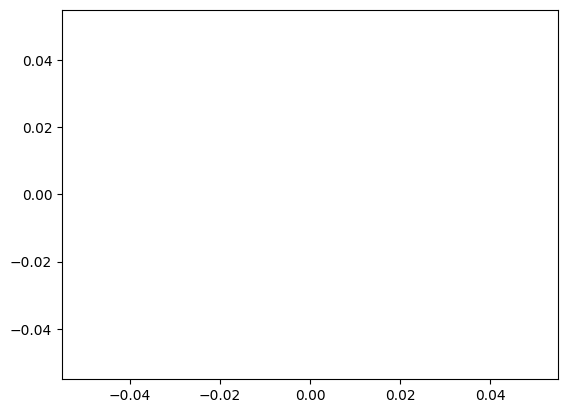

In [9]:

data.columns

#lets get a look at the number of players over time, but only for the isAvailableToPlay column
data.loc[data['isAvailableToPlay'] == 'T', 'player_on_planet'].plot()

In [10]:
data = data.sort_values(['name', 'timestamp'])

data['next_total_deaths'] = data.groupby('name')['helldiver_deaths_total'].shift(-1)

data['helldiver_deaths_1hour_diff'] = (
    data['next_total_deaths'] - data['helldiver_deaths_total']
)

In [11]:
#lets make the isAvailableToPlay column a boolean based on the helldiver_deaths_1hour_diff column, if the value is zero then 
# planet is not available to play, if the value is greater than zero since it'll always be positive or zero 

data['isAvailableToPlay'] = data['helldiver_deaths_1hour_diff'] > 0

In [12]:
data.loc[data['isAvailableToPlay'] == True]

,timestamp,planet_index,name,sector,biome,planet_environ_hazards,player_on_planet,isAvailableToPlay,in_major_order,missions_won,...,planet_health,max_planet_health,major_order_dispatch,enemy_attacking_planet,enemy_attacking_owner,major_order_planet_captured,DSS_present,Y-M-D,CST_H_M_S,next_total_deaths
129,2026-03-25 20:10:13.834117,129.0,ACAMAR IV,Jin Xi,Plains,NaN,10.0,True,F,10388278.0,...,1500000.0,1500000.0,"Liberate Hort before it falls into the Void, a...",128.0,Terminids,F,F,2026-03-25,20:10:13,79673933.0
393,2026-03-25 20:29:03.488618,129.0,ACAMAR IV,Jin Xi,Plains,NaN,6.0,True,F,10388279.0,...,1500000.0,1500000.0,"Liberate Hort before it falls into the Void, a...",214.0,Terminids,F,F,2026-03-25,20:29:03,79673937.0
657,2026-03-25 20:47:39.633083,129.0,ACAMAR IV,Jin Xi,Plains,NaN,7.0,True,F,10388280.0,...,1500000.0,1500000.0,"Liberate Hort before it falls into the Void, a...",214.0,Terminids,F,F,2026-03-25,20:47:39,79673947.0
921,2026-03-25 21:46:53.427685,129.0,ACAMAR IV,Jin Xi,Plains,NaN,0.0,True,F,10388281.0,...,1500000.0,1500000.0,"Liberate Hort before it falls into the Void, a...",214.0,Terminids,F,F,2026-03-25,21:46:53,79673951.0
1185,2026-03-25 23:41:16.854818,129.0,ACAMAR IV,Jin Xi,Plains,NaN,7.0,True,F,10388281.0,...,1500000.0,1500000.0,"Liberate Hort before it falls into the Void, a...",214.0,Terminids,F,F,2026-03-25,23:41:16,79673960.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68101,2026-04-12 19:47:05.395005,253.0,ZZANIAH PRIME,Gellert,Desert Dunes,Sandstorms,3.0,True,F,2819379.0,...,1000000.0,1000000.0,Complete the requisite number of missions to a...,NaN,NaN,F,F,2026-04-12,19:47:05,20124910.0
68365,2026-04-12 21:40:53.379562,253.0,ZZANIAH PRIME,Gellert,Desert Dunes,Sandstorms,0.0,True,F,2819380.0,...,1000000.0,1000000.0,Complete the requisite number of missions to a...,NaN,NaN,F,F,2026-04-12,21:40:53,20124919.0
68893,2026-04-12 23:41:40.662034,253.0,ZZANIAH PRIME,Gellert,Desert Dunes,Sandstorms,2.0,True,F,2819381.0,...,1000000.0,1000000.0,NaN,NaN,NaN,F,F,2026-04-12,23:41:40,20124926.0
69157,2026-04-13 03:30:50.189103,253.0,ZZANIAH PRIME,Gellert,Desert Dunes,Sandstorms,0.0,True,F,2819381.0,...,1000000.0,1000000.0,Complete the requisite number of missions to a...,NaN,NaN,F,F,2026-04-13,03:30:50,20124941.0


In [13]:
data.loc[data['in_major_order']=='T'].tail(5)

,timestamp,planet_index,name,sector,biome,planet_environ_hazards,player_on_planet,isAvailableToPlay,in_major_order,missions_won,...,planet_health,max_planet_health,major_order_dispatch,enemy_attacking_planet,enemy_attacking_owner,major_order_planet_captured,DSS_present,Y-M-D,CST_H_M_S,next_total_deaths
21610,2026-03-31 07:25:20.203955,226.0,RIRGA BAY,Rigel,Acidic Badlands,Acid Storms,19893.0,True,T,3232255.0,...,364053.0,1200000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,T,2026-03-31,07:25:20,1.020966e+09
21874,2026-03-31 09:08:54.527285,226.0,RIRGA BAY,Rigel,Acidic Badlands,Acid Storms,18096.0,True,T,3253653.0,...,275546.0,1200000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,T,2026-03-31,09:08:54,1.021084e+09
22138,2026-03-31 11:00:15.317566,226.0,RIRGA BAY,Rigel,Acidic Badlands,Acid Storms,20300.0,True,T,3277939.0,...,180812.0,1200000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,T,2026-03-31,11:00:15,1.021153e+09
22402,2026-03-31 11:57:12.893259,226.0,RIRGA BAY,Rigel,Acidic Badlands,Acid Storms,23703.0,True,T,3292114.0,...,131504.0,1200000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,T,2026-03-31,11:57:12,1.021348e+09
22666,2026-03-31 13:55:37.127624,226.0,RIRGA BAY,Rigel,Acidic Badlands,Acid Storms,35763.0,True,T,3332077.0,...,25208.0,1200000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,T,2026-03-31,13:55:37,1.021496e+09


In [14]:
data.loc[(data['in_major_order']=='T') ].tail()

#data.loc[(data['name']=='MARFARK')].tail()

,timestamp,planet_index,name,sector,biome,planet_environ_hazards,player_on_planet,isAvailableToPlay,in_major_order,missions_won,...,planet_health,max_planet_health,major_order_dispatch,enemy_attacking_planet,enemy_attacking_owner,major_order_planet_captured,DSS_present,Y-M-D,CST_H_M_S,next_total_deaths
21610,2026-03-31 07:25:20.203955,226.0,RIRGA BAY,Rigel,Acidic Badlands,Acid Storms,19893.0,True,T,3232255.0,...,364053.0,1200000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,T,2026-03-31,07:25:20,1.020966e+09
21874,2026-03-31 09:08:54.527285,226.0,RIRGA BAY,Rigel,Acidic Badlands,Acid Storms,18096.0,True,T,3253653.0,...,275546.0,1200000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,T,2026-03-31,09:08:54,1.021084e+09
22138,2026-03-31 11:00:15.317566,226.0,RIRGA BAY,Rigel,Acidic Badlands,Acid Storms,20300.0,True,T,3277939.0,...,180812.0,1200000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,T,2026-03-31,11:00:15,1.021153e+09
22402,2026-03-31 11:57:12.893259,226.0,RIRGA BAY,Rigel,Acidic Badlands,Acid Storms,23703.0,True,T,3292114.0,...,131504.0,1200000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,T,2026-03-31,11:57:12,1.021348e+09
22666,2026-03-31 13:55:37.127624,226.0,RIRGA BAY,Rigel,Acidic Badlands,Acid Storms,35763.0,True,T,3332077.0,...,25208.0,1200000.0,"Liberate Hort before it falls into the Void, a...",NaN,NaN,F,T,2026-03-31,13:55:37,1.021496e+09


In [15]:
data.columns

Index(['timestamp', 'planet_index', 'name', 'sector', 'biome',
       'planet_environ_hazards', 'player_on_planet', 'isAvailableToPlay',
       'in_major_order', 'missions_won', 'missions_lost',
       'is_humans_defending', 'helldiver_deaths_total',
       'helldiver_deaths_1hour_diff', 'bullets_fired', 'bullets_hit',
       'illuminate_killed', 'terminids_killed', 'automatons_killed',
       'currentOwner', 'major_order_completed', 'planet_health',
       'max_planet_health', 'major_order_dispatch', 'enemy_attacking_planet',
       'enemy_attacking_owner', 'major_order_planet_captured', 'DSS_present',
       'Y-M-D', 'CST_H_M_S', 'next_total_deaths'],
      dtype='object')

In [16]:
data.loc[(data['in_major_order'] == 'T') & (data['name'] == 'CHOEPESSA IV')].tail(5)

,timestamp,planet_index,name,sector,biome,planet_environ_hazards,player_on_planet,isAvailableToPlay,in_major_order,missions_won,...,planet_health,max_planet_health,major_order_dispatch,enemy_attacking_planet,enemy_attacking_owner,major_order_planet_captured,DSS_present,Y-M-D,CST_H_M_S,next_total_deaths
69326,2026-04-13 06:20:47.133782,158.0,CHOEPESSA IV,Trigon,Boneyard,NaN,14881.0,True,T,10559296.0,...,2018725.0,3200000.0,Complete the requisite number of missions to a...,NaN,NaN,F,T,2026-04-13,06:20:47,77266097.0
69590,2026-04-13 09:04:29.221398,158.0,CHOEPESSA IV,Trigon,Boneyard,NaN,10746.0,True,T,10582788.0,...,2017646.0,3200000.0,Complete the requisite number of missions to a...,NaN,NaN,F,T,2026-04-13,09:04:29,77378380.0
69854,2026-04-13 11:21:17.886690,158.0,CHOEPESSA IV,Trigon,Boneyard,NaN,13880.0,True,T,10602039.0,...,1109951.0,3200000.0,NaN,NaN,NaN,F,T,2026-04-13,11:21:17,77556803.0
70118,2026-04-13 13:53:43.902956,158.0,CHOEPESSA IV,Trigon,Boneyard,NaN,21929.0,True,T,10632826.0,...,1091777.0,3200000.0,Complete the requisite number of missions to a...,NaN,NaN,F,T,2026-04-13,13:53:43,77694974.0
70382,2026-04-13 15:20:39.915801,158.0,CHOEPESSA IV,Trigon,Boneyard,NaN,22776.0,False,T,10655559.0,...,1082624.0,3200000.0,Complete the requisite number of missions to a...,NaN,NaN,F,T,2026-04-13,15:20:39,NaN


In [17]:
#add some more feature engineering

#from personal experience i know some players will player on only certain major order planets that have certain factions, 
# aka where "bugdivers" terms come from is they only play against terminids

#so we need to look for the major order planet and who is attacking that planet or currently holding it, as long as its 
# not humans it should give us the right answer because there has never been an instance of automatons, illuminate, terminids taking 
# over any other factions planets other than humans


data['major_order_enemies'] = d

NameError: name 'd' is not defined

In [ ]:
#guess the player count based on a planet we give it. We are trying to take into account if the planet is in major, 
# what faction it is, if humans are defending, the biome, the hazards, and the time and date

#we might also look into the major order dispatch to see what the challenge is, maybe some players don't like certain challenges. 

#we could also look at how many days in the major order has been and see if players get bored after player a certain major order for so long, for ex:
#maybe players get bored defending after 2 days, but like capturing planets for 4 days, these will drastically change the player count on the planet 


In [18]:
data.columns

Index(['timestamp', 'planet_index', 'name', 'sector', 'biome',
       'planet_environ_hazards', 'player_on_planet', 'isAvailableToPlay',
       'in_major_order', 'missions_won', 'missions_lost',
       'is_humans_defending', 'helldiver_deaths_total',
       'helldiver_deaths_1hour_diff', 'bullets_fired', 'bullets_hit',
       'illuminate_killed', 'terminids_killed', 'automatons_killed',
       'currentOwner', 'major_order_completed', 'planet_health',
       'max_planet_health', 'major_order_dispatch', 'enemy_attacking_planet',
       'enemy_attacking_owner', 'major_order_planet_captured', 'DSS_present',
       'Y-M-D', 'CST_H_M_S', 'next_total_deaths'],
      dtype='object')

In [19]:
#first objective is to look at the number of helldivers active on the days and see if there are high valleys on say friday and saturday, 
# but not as high valleys on say tuesday, wednesday, thursday 

#we need to add another column called day_of_week to see what day it is


# Convert to datetime
data['Y-M-D'] = pd.to_datetime(data['Y-M-D'])

# Create new column for day of week (full name like Monday, Tuesday, etc.)
data['day_of_week'] = data['Y-M-D'].dt.day_name()



In [ ]:
median_players_on_planet = data.groupby(['name'])['player_on_planet'].median()
#below adds the rows to data dataframe
#getting the median players on planet
median_players_on_planet = data.groupby(['name'])['player_on_planet'].transform('median')
#getting the median player on planet by day of week and planet name
median_players_on_planet_day_of_week = data.groupby(['name', 'day_of_week'])['player_on_planet'].transform('median')
#getting median players per day of week
median_players_per_day = data.groupby('day_of_week')['player_on_planet'].transform('median')

In [ ]:
#now lets get the median player_on_planet of planets in_major_order and look at the peaks and valleys afterward, 
# then we can analyze the major order dispatch and the challenges to see if there is a correlation with player count on the planet
mo_data = data[data['in_major_order'] == 'T']

median_mo = (
    mo_data
    .groupby('name')['player_on_planet']
    .median()
    .sort_values(ascending=False)
)

mo_time = (
    mo_data
    .groupby(['timestamp', 'name'])['player_on_planet']
    .median()
    .reset_index()
)

In [ ]:
#now lets get the median value of player_counts on each day of the week and groupby planet

day_of_week
Saturday     13728
Sunday       13464
Friday       10824
Thursday     10560
Monday        8448
Wednesday     6864
Tuesday       6600
Name: count, dtype: int64